PINC LO = 91912300
fs_out  = 192012 sps
Tono TX : 10.709547 MHz (offset = 9.547 kHz)
Buffer  : 1041664 muestras (32552 rafagas) = 8.33 ms



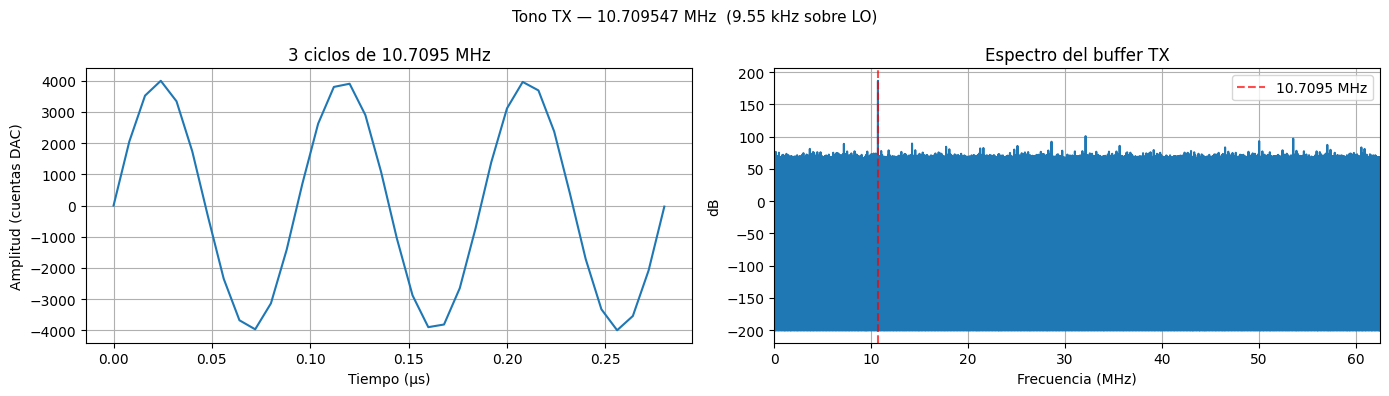

Conectado.
Cargando 1041664 muestras al buffer TX (DDR)...
  ACK: 0x01
  ACK: 0x01
  ACK: 0x01
  ACK: 0x01
Reseteando FIFO RX...
  ACK: 0x01
  ACK: 0x01
Pidiendo 4096 muestras complejas (32768 bytes)...
  4/32768 bytes
  1464/32768 bytes
  4384/32768 bytes
  5844/32768 bytes
  6772/32768 bytes
  8232/32768 bytes
  9692/32768 bytes
  11308/32768 bytes
  14228/32768 bytes
  15688/32768 bytes
  16728/32768 bytes
  18188/32768 bytes
  19648/32768 bytes
  21108/32768 bytes
  22568/32768 bytes
  24016/32768 bytes
  25476/32768 bytes
  26936/32768 bytes
  28396/32768 bytes
  29844/32768 bytes
  32764/32768 bytes
  32768/32768 bytes
  ACK: 0x01


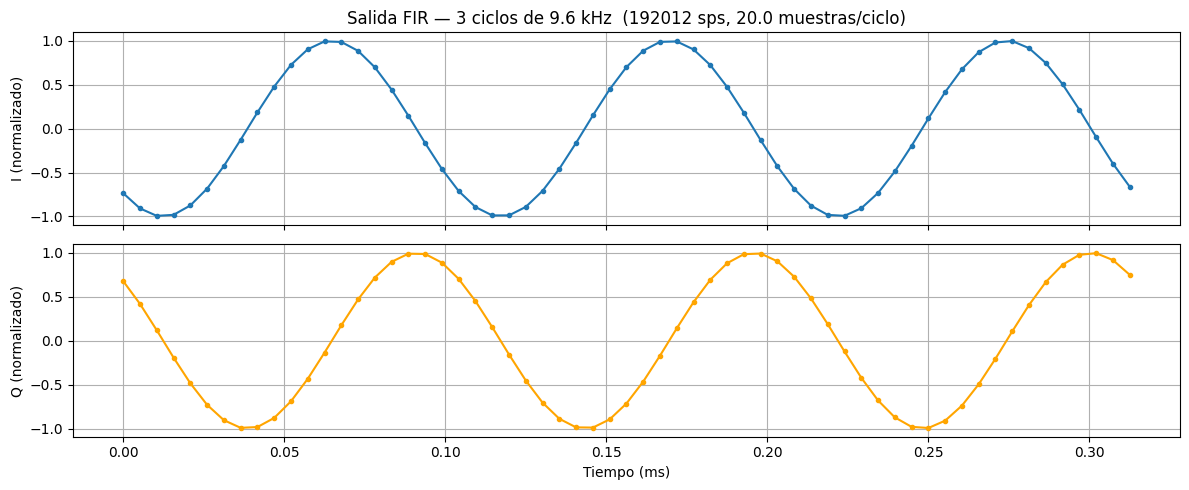

Pico en: 9.5631 kHz (esperado: 9.5474 kHz)


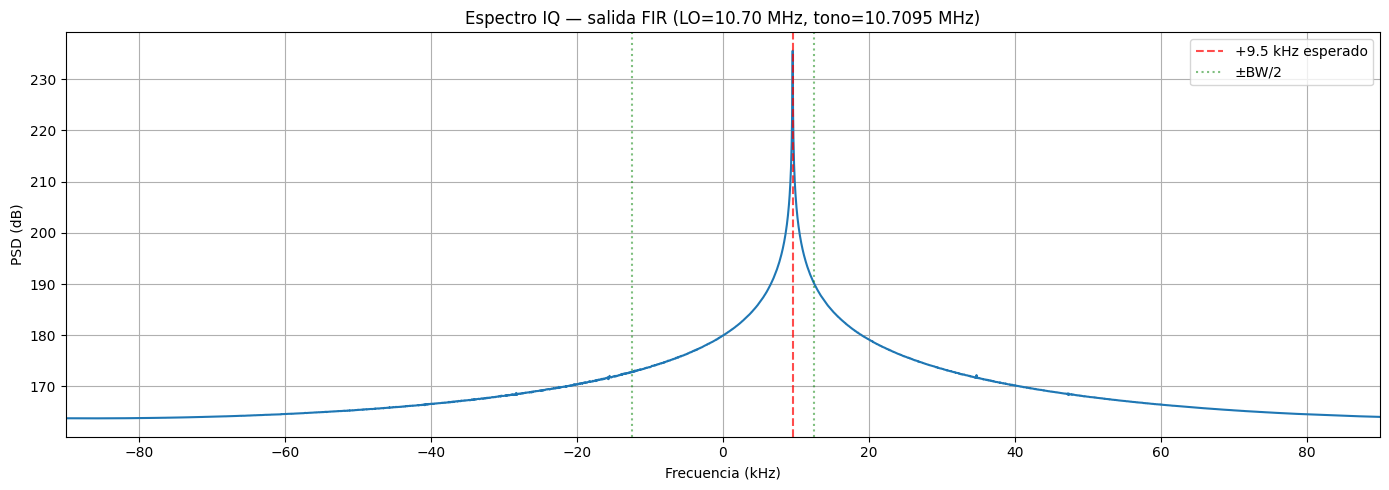

Listo.


In [35]:
"""
Prueba de loopback: genera un tono a 10.7 MHz + 9.6 kHz, lo carga en el
buffer TX (DDR, leido en loop por el axis_ram_reader), lo transmite por el
DAC, y lo recibe por el ADC.
El receptor mezcla con el DDS a 10.7 MHz -> la salida del FIR debe
mostrar un tono en banda base a 9.6 kHz.
"""

import socket
import struct
import time
import numpy as np
import matplotlib.pyplot as plt

HOST = '10.19.216.50'
PORT = 1003

CMD_READ_ADC = 0x03
CMD_SET_FIFO = 0x04
CMD_SET_CFG  = 0x05
CMD_TX_LOAD  = 0x06
CMD_TX_START = 0x07
CMD_TX_STOP  = 0x08

FS       = 125e6
fs_out   = 125e6/651      # tasa de salida real medida en la board (CIC R=651, FIR single rate)
f_lo_hz  = 10.7e6       # frecuencia del LO receptor
f_offset = 9.6e3        # offset deseado en banda base

f_tx_nom = f_lo_hz + f_offset   # 10.7096 MHz

f_min_khz = -90.0
f_max_khz =  90.0

TX_BURST_SAMPLES = 32   # axis_ram_reader: 16 beats x 2 muestras/beat (AXI_DATA_WIDTH=64)

PINC = round(f_lo_hz / FS * (1 << 30))
CFG_VAL_RESET = (PINC << 1) | 0
CFG_VAL_RUN   = (PINC << 1) | 1

# ============================================================
# GENERACION DEL TONO TX
# ============================================================
def generar_tono_tx(fc_nom, n_bits_dur=80, amplitud=4000):
    """
    Genera un tono sinusoidal ajustado al bin mas cercano de la FFT
    del buffer, para que cierre en loop sin glitch de fase.
    El largo se redondea a un multiplo de TX_BURST_SAMPLES porque el
    axis_ram_reader lee en rafagas fijas de 32 muestras.
    """
    sps_int = round(FS / 9600)               # muestras/bit de AIS
    N_ideal = n_bits_dur * sps_int
    N = int(round(N_ideal / TX_BURST_SAMPLES) * TX_BURST_SAMPLES)
    if N == 0:
        N = TX_BURST_SAMPLES

    k = round(N * fc_nom / FS)
    fc_real = k * FS / N

    t = np.arange(N) / FS
    tono = (np.sin(2 * np.pi * fc_real * t) * amplitud).astype(np.int16)
    words = (tono.astype(np.int32) & 0x3FFF)   # bits[13:0] = DAC canal A, DAC canal B = 0
    return words, fc_real, N

# ============================================================
# COMUNICACION
# ============================================================
def send_cmd(sock, cmd, payload):
    sock.sendall(struct.pack('B', cmd))
    sock.sendall(struct.pack('I', payload))

def read_ack(sock):
    data = sock.recv(1)
    print(f"  ACK: 0x{data[0]:02X}")
    return data[0] == 0x01

def read_adc(sock, n_samples):
    n_words = n_samples * 2
    print("Reseteando FIFO RX...")
    send_cmd(sock, CMD_SET_FIFO, 0); read_ack(sock)
    send_cmd(sock, CMD_SET_FIFO, 1); read_ack(sock)
    print(f"Pidiendo {n_samples} muestras complejas ({n_words*4} bytes)...")
    send_cmd(sock, CMD_READ_ADC, n_words)
    raw = b''
    total = n_words * 4
    while len(raw) < total:
        chunk = sock.recv(total - len(raw))
        raw += chunk
        print(f"  {len(raw)}/{total} bytes")
    words = struct.unpack(f'{n_words}i', raw)
    I_bb = np.array(words[0::2], dtype=float)
    Q_bb = np.array(words[1::2], dtype=float)
    return I_bb, Q_bb

# ============================================================
# GENERACION Y GRAFICA DEL TONO TX (antes de conectar)
# ============================================================
words_tx, fc_real, N_buf = generar_tono_tx(f_tx_nom)

print(f"PINC LO = {PINC}")
print(f"fs_out  = {fs_out:.0f} sps")
print(f"Tono TX : {fc_real/1e6:.6f} MHz (offset = {(fc_real-f_lo_hz)/1e3:.3f} kHz)")
print(f"Buffer  : {N_buf} muestras ({N_buf // TX_BURST_SAMPLES} rafagas) = {N_buf/FS*1e3:.2f} ms")
print()

n_plot = min(4096, N_buf)
t_plot = np.arange(n_plot) / FS * 1e6   # µs
tono_real = (words_tx[:n_plot].astype(np.int32) << 18 >> 18).astype(float)

n_ciclos = 3
t_3ciclos = n_ciclos / fc_real * 1e6
mask = t_plot < t_3ciclos

tono_real_full = (words_tx.astype(np.int32) << 18 >> 18).astype(float)
F     = np.fft.rfft(tono_real_full, n=N_buf)
f_fft = np.fft.rfftfreq(N_buf, d=1/FS) / 1e6
Pxx   = 20 * np.log10(np.abs(F) + 1e-10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle(f'Tono TX — {fc_real/1e6:.6f} MHz  ({(fc_real-f_lo_hz)/1e3:.2f} kHz sobre LO)', fontsize=11)

ax1.plot(t_plot[mask], tono_real[mask])
ax1.set_xlabel('Tiempo (µs)')
ax1.set_ylabel('Amplitud (cuentas DAC)')
ax1.set_title(f'{n_ciclos} ciclos de {fc_real/1e6:.4f} MHz')
ax1.grid(True)

ax2.plot(f_fft, Pxx)
ax2.axvline(fc_real/1e6, color='r', ls='--', alpha=0.7, label=f'{fc_real/1e6:.4f} MHz')
ax2.set_xlabel('Frecuencia (MHz)')
ax2.set_ylabel('dB')
ax2.set_title('Espectro del buffer TX')
ax2.set_xlim(0, 62.5)
ax2.legend(); ax2.grid(True)
plt.tight_layout()
plt.savefig('tono_tx_verif.png', dpi=110)
plt.show()

# ============================================================
# LOOPBACK
# ============================================================
sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
sock.connect((HOST, PORT))
print("Conectado.")

# Cargar y arrancar TX
print(f"Cargando {len(words_tx)} muestras al buffer TX (DDR)...")
send_cmd(sock, CMD_TX_LOAD, len(words_tx))
sock.sendall(words_tx.astype(np.int32).tobytes())
read_ack(sock)
send_cmd(sock, CMD_TX_START, 0)
read_ack(sock)
time.sleep(0.1)

# Configurar LO receptor
send_cmd(sock, CMD_SET_CFG, CFG_VAL_RESET); read_ack(sock)
send_cmd(sock, CMD_SET_CFG, CFG_VAL_RUN);   read_ack(sock)

# Capturar ADC
n_samples = 4096
I_bb, Q_bb = read_adc(sock, n_samples)

# Detener TX
send_cmd(sock, CMD_TX_STOP, 0); read_ack(sock)
sock.close()

# ============================================================
# GRAFICAS — TEMPORAL (despues de recibir del ADC)
# ============================================================
t = np.arange(n_samples) / fs_out * 1e3   # ms
muestras_por_ciclo = fs_out / f_offset

n_ciclos_bb = 3
t_max = n_ciclos_bb / f_offset * 1e3
mask_t = t < t_max

I_norm = I_bb / (np.max(np.abs(I_bb)) + 1e-10)
Q_norm = Q_bb / (np.max(np.abs(Q_bb)) + 1e-10)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
ax1.plot(t[mask_t], I_norm[mask_t], 'o-', markersize=3)
ax1.set_ylabel('I (normalizado)')
ax1.set_title(f'Salida FIR — {n_ciclos_bb} ciclos de {f_offset/1e3:.1f} kHz  '
              f'({fs_out:.0f} sps, {muestras_por_ciclo:.1f} muestras/ciclo)')
ax1.grid(True)
ax2.plot(t[mask_t], Q_norm[mask_t], 'o-', markersize=3, color='orange')
ax2.set_ylabel('Q (normalizado)')
ax2.set_xlabel('Tiempo (ms)')
ax2.grid(True)
plt.tight_layout()
plt.show()

# ============================================================
# GRAFICAS — ESPECTRO COMPLEJO
# ============================================================
S     = np.fft.fftshift(np.fft.fft(I_bb + 1j * Q_bb))
freqs = np.fft.fftshift(np.fft.fftfreq(n_samples, d=1/fs_out))
Pxx   = 10 * np.log10(np.abs(S)**2 + 1e-20)

freq_peak = freqs[np.argmax(Pxx)]
print(f"Pico en: {freq_peak/1e3:.4f} kHz (esperado: {(fc_real-f_lo_hz)/1e3:.4f} kHz)")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(freqs/1e3, Pxx)
ax.axvline( f_offset/1e3, color='r', ls='--', alpha=0.7,
            label=f'+{(fc_real-f_lo_hz)/1e3:.1f} kHz esperado')
ax.axvline( 12.5, color='g', ls=':', alpha=0.5, label='±BW/2')
ax.axvline(-12.5, color='g', ls=':', alpha=0.5)
ax.set_xlabel('Frecuencia (kHz)')
ax.set_ylabel('PSD (dB)')
ax.set_title(f'Espectro IQ — salida FIR (LO={f_lo_hz/1e6:.2f} MHz, tono={fc_real/1e6:.4f} MHz)')
ax.set_xlim(f_min_khz, f_max_khz)
ax.legend(); ax.grid(True)
plt.tight_layout()
plt.show()

print("Listo.")